## **Shaghayegh Bagheri** 


## **Statistical Analysis in Capital Markets project**

____________________________________________________________________________________________________________

# **Before explaining the code**
 I should mention that I cleaned and organized the Excel files by keeping only the data from the past two years and removing older records. I did all that in Excel .


## **Question 1 : part 1**
In this section, I first read all ten Excel files corresponding to different companies, calculated the returns for each of them, and created a table showing the mean and standard deviation for each company. Finally, I visualized their differences using a scatter plot, which I will interpret in the following part.

**Further explanations for each line of code are provided as comments next to them**


In [10]:
import pandas as pd # type: ignore

# putting all the file names in one list 
file_names = [
    "Bargh Mapna Co.xlsx",
    "Damavand Co.xlsx",
    "Fajr E.Persia Gulf.xlsx",
    "Gilan Elec. Dev.xlsx",
    "Mobin Petr.xlsx",
    "Nirou Inv.xlsx",
    "Omid Taban Hoor.xlsx",
    "Peyvand Gostar.xlsx",
    "Saba SoutWestPower.xlsx",
    "Zagros Kosar Power.xlsx"
    
]

In [11]:
returns_dict = {}

for file in file_names:
    df = pd.read_excel(file)

    # calculating Return for each company 
    daily_returns = [None]
    for i in range(1, len(df)):
        prev = df.loc[i - 1, '<CLOSE>']
        curr = df.loc[i, '<CLOSE>']
        ret = (curr - prev) / prev
        daily_returns.append(ret)

    df['Daily Return'] = daily_returns

    # using just Data and Return becouse we want to make a Dataframe with them.
    temp = df[['<DTYYYYMMDD>', 'Daily Return']].dropna()
    temp = temp.set_index('<DTYYYYMMDD>')

    # Extracting the company name
    company_name = file.replace('.xlsx', '')

    # adding company name to dictionary.
    returns_dict[company_name] = temp['Daily Return']

# Building the final dataframe with the dictionary.
returns_df = pd.DataFrame(returns_dict)


print(returns_df.head())

              Bargh Mapna Co  Damavand Co  Fajr E.Persia Gulf  \
<DTYYYYMMDD>                                                    
20230606           -0.022690    -0.008114            0.004443   
20230607            0.007463     0.002045           -0.000804   
20230610           -0.049383    -0.044898           -0.008451   
20230611           -0.038961    -0.006410           -0.004464   
20230612           -0.028829    -0.045161           -0.012638   

              Gilan Elec. Dev  Mobin Petr  Nirou Inv  Omid Taban Hoor  \
<DTYYYYMMDD>                                                            
20230606             0.037634   -0.000538  -0.050606         0.013105   
20230607             0.013472   -0.002152  -0.016380        -0.026997   
20230610            -0.018405   -0.049070  -0.068586        -0.047399   
20230611            -0.008333   -0.005387  -0.018788        -0.010316   
20230612            -0.043067   -0.018814  -0.056516        -0.032495   

              Peyvand Gostar  Sa

Now we calculate the Mean and Sd for all 10 companies.

In [12]:
# calculate the Mean and Sd for all 10 companies
mean_returns = returns_df.mean()
std_returns = returns_df.std()

# building the Dataframe.
summary_df = pd.DataFrame({
    'Mean Return': mean_returns,
    'Standard Deviation': std_returns
})


print(summary_df)

# Saving to an output Excel file.
#summary_df.to_excel("Return_Summary_Table_Number2.xlsx")


                    Mean Return  Standard Deviation
Bargh Mapna Co        -0.001461            0.031779
Damavand Co           -0.001549            0.031190
Fajr E.Persia Gulf    -0.000016            0.042581
Gilan Elec. Dev       -0.000160            0.016067
Mobin Petr            -0.001277            0.033013
Nirou Inv              0.001555            0.031522
Omid Taban Hoor        0.000461            0.016081
Peyvand Gostar        -0.000444            0.022263
Saba SoutWestPower     0.000000            0.000000
Zagros Kosar Power    -0.000817            0.021973


Plotting an appropriate chart to display the mean and standard deviation of the ten companies.

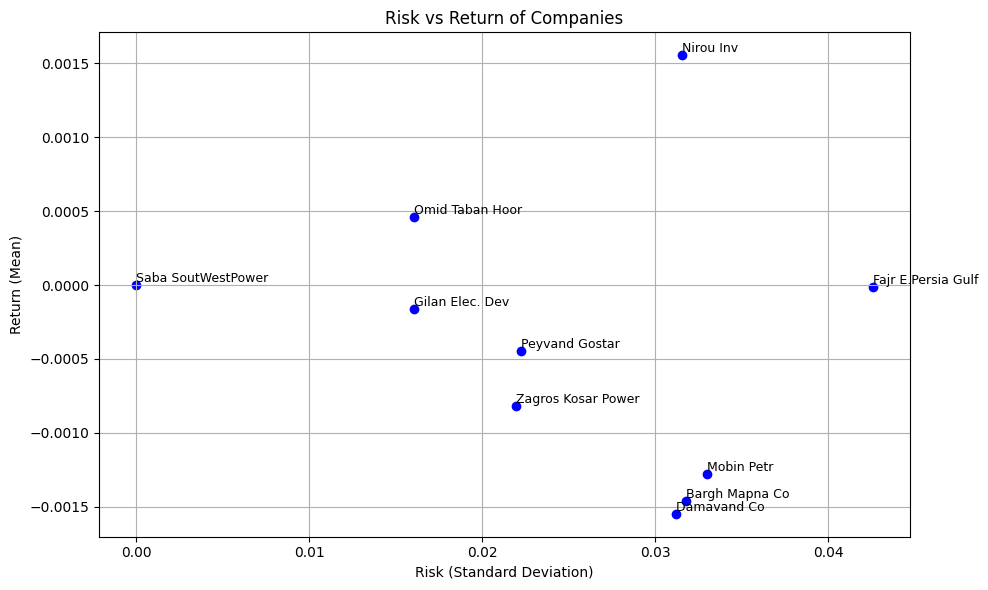

In [13]:
import matplotlib.pyplot as plt # type: ignore

plt.figure(figsize=(10, 6))

# plot scatters. 
plt.scatter(summary_df['Standard Deviation'], summary_df['Mean Return'], color='blue')

# Label the name of each company next to its scatter in plot. 
for company in summary_df.index:
    x = summary_df.loc[company, 'Standard Deviation']
    y = summary_df.loc[company, 'Mean Return']
    plt.text(x, y, company, fontsize=9, ha='left', va='bottom')

plt.xlabel('Risk (Standard Deviation)')
plt.ylabel('Return (Mean)')
plt.title('Risk vs Return of Companies')
plt.grid(True)

plt.tight_layout()
plt.show()


**Chart Interpretation**

1) Best Investment Option (High Return, Moderate Risk) is **Nirou Inv** which is Nirou investment company. 
-Its Return has the highest mean of all companies. 
-The Risk level is moderate (~0.031)
-Overall this company offers a favorible balance between risk and return.

2) The **WORST** option (Negative Return, High Risk) **Damavand Co** which is Damavand Power Generation Company.
-It has the lowest mean Return.
-Risk level is not acceptable in comparison of the low return. 

3) High Risk with No Return (Unfavorable) : **Fair EI Persia Gulf** which is Fajr Energy Persian Gulf Company.
-Return is close to zero.
-Risk is quite high (>0.04).
-Not an attractive investment: taking on high risk without any expected reward.

4) The LOWEST Risk is for **Saba SouthWestPower** which is Power generation in southwest Sabah.
-Almost zero risk (standard deviation ≈ 0).
-Also close to zero return.

## **part 2**

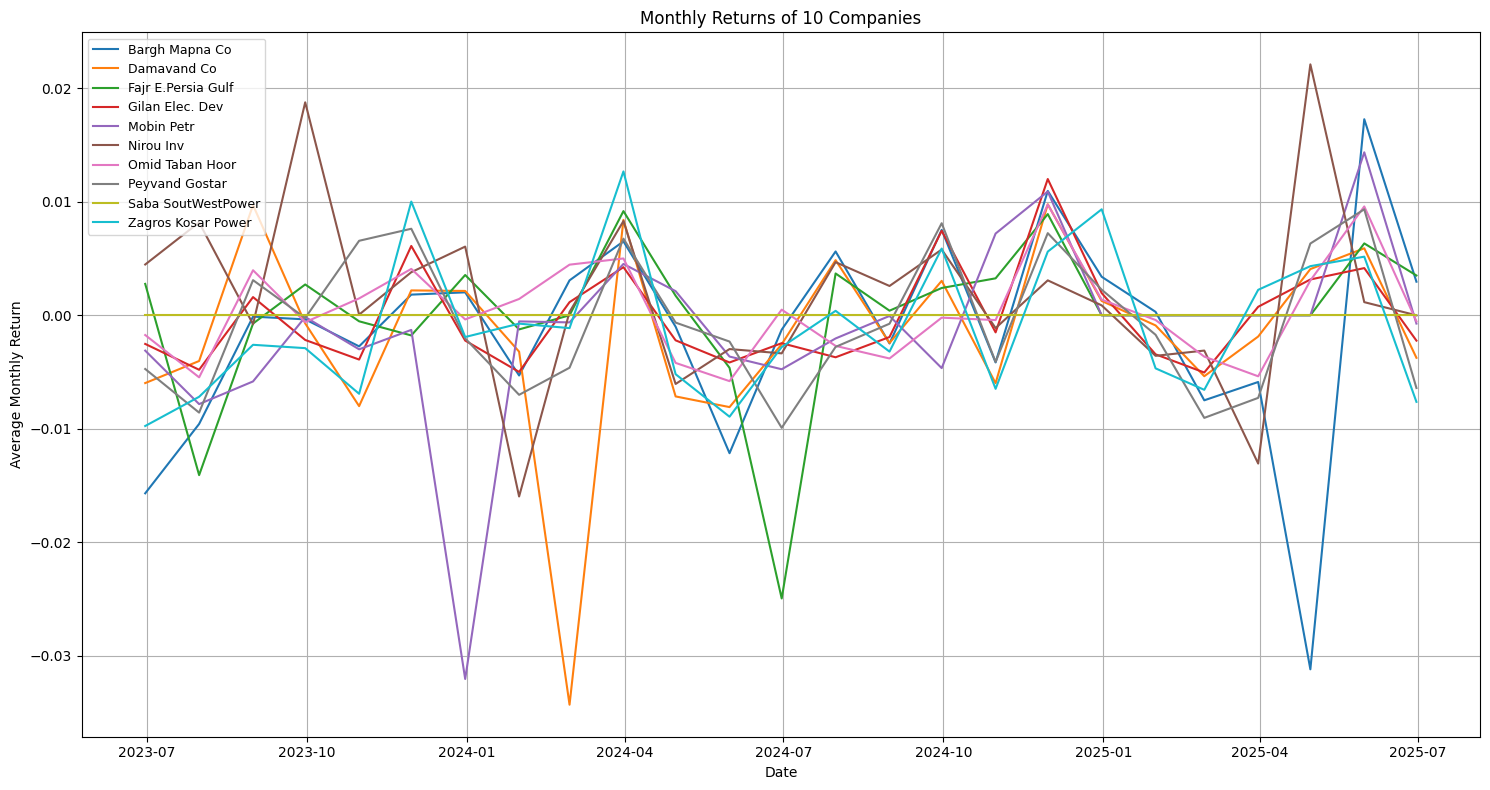

In [14]:

# converting datetime to index
returns_df.index = pd.to_datetime(returns_df.index, format='%Y%m%d')


# calculating monthly return = the average of daily return in every month
monthly_returns = returns_df.resample('ME').mean()

# plot time serires of monthly return
plt.figure(figsize=(15, 8))

for company in monthly_returns.columns:
    plt.plot(monthly_returns.index, monthly_returns[company], label=company)

plt.title('Monthly Returns of 10 Companies')
plt.xlabel('Date')
plt.ylabel('Average Monthly Return')
plt.legend(loc='upper left', fontsize=9)
plt.grid(True)
plt.tight_layout()
plt.show()


## **Plot Explanation :** 

This chart is a time series of the monthly returns of 10 different companies. The horizontal axis represents the date, marked monthly from summer 2023 to summer 2025, and the vertical axis shows the monthly return of each company. Each line in the plot represents one company, distinguished by different colors and identified using the plot legend.

## **Interpretation of the plot :**

1) **Growth Periods =**
 Several companies had positive returns in Fall 2023 and Spring 2024, meaning their lines were upward and above zero during those months. For example, the highest return observed in the entire plot belongs to **Nirou Inv**. However, as shown, its return was negative in some months, with significant declines. The second company with a relatively high return is **Zagros Kosar Power**, whose fluctuations are greater than those of **Nirou Inv**.

2) **Sharp Decline Periods =** 
In Winter 2023 and Summer 2024, most companies experienced a decrease in returns. As clearly shown in the plot, the companies with the most significant drop in returns compared to the others are **Damavand Co**, **Mobin Petr**, and **Bargh Mapna Co**. These companies had returns below zero for most of the time.

3) **Low Volatility =**
Companies like **Saba SouthWestPower** stayed almost always close to zero → meaning they have stable or low-fluctuation returns.

## **Part 3** 

Sample Correlation Matrix of Monthly Returns:
                    Bargh Mapna Co  Damavand Co  Fajr E.Persia Gulf  \
Bargh Mapna Co            1.000000     0.193079            0.316623   
Damavand Co               0.193079     1.000000            0.229408   
Fajr E.Persia Gulf        0.316623     0.229408            1.000000   
Gilan Elec. Dev           0.397060     0.400282            0.393924   
Mobin Petr                0.210713     0.063863            0.276938   
Nirou Inv                -0.194023     0.243996            0.157600   
Omid Taban Hoor           0.463353     0.274538            0.349608   
Peyvand Gostar            0.321206     0.472617            0.508951   
Saba SoutWestPower             NaN          NaN                 NaN   
Zagros Kosar Power        0.394843     0.464666            0.306214   

                    Gilan Elec. Dev  Mobin Petr  Nirou Inv  Omid Taban Hoor  \
Bargh Mapna Co             0.397060    0.210713  -0.194023         0.463353   
Damavand Co   

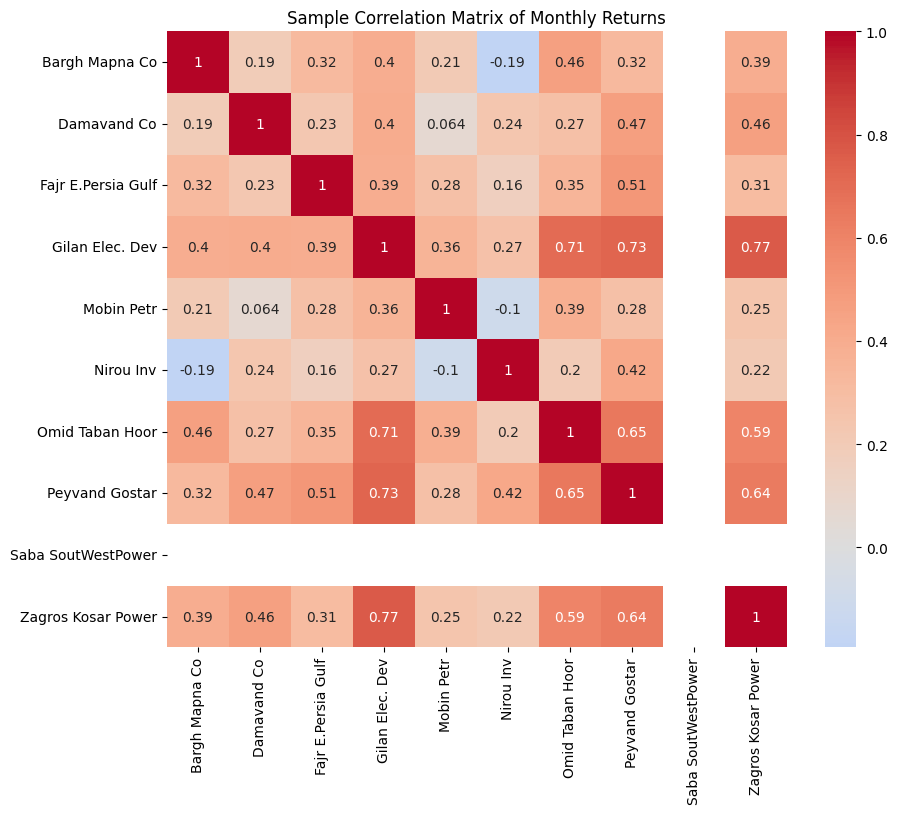

In [15]:

# calculate the monthly sample corrolation matrix 
monthly_corr_matrix = monthly_returns.corr()

print("Sample Correlation Matrix of Monthly Returns:")
print(monthly_corr_matrix)

# plotting the monthly sample corrolation matrix
import seaborn as sns # type: ignore


plt.figure(figsize=(10, 8))
sns.heatmap(monthly_corr_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Sample Correlation Matrix of Monthly Returns')
plt.show()


## **Interpretation of the companies’ correlation:**

**Overall meaning of the correlation matrix:**

-Each number in the matrix shows the strength of the linear correlation between the monthly returns of two companies.

-A value of 1 means perfect positive correlation (the two companies move up and down exactly together).

-A value close to zero means almost no correlation (the return behaviors are independent of each other).

-A negative value means inverse correlation (when one grows, the other usually declines).

**Key points in this matrix:**

1) The main diagonal of the matrix is filled with 1s, which is expected because it represents the correlation of each company with itself.

2) For example, the correlation between **Gilan Elec. Dev** and **Zagros Kosar Power** is around 0.77, indicating that their monthly returns are strongly related and they show similar behavior.

3) **Gilan Elec. Dev** also has high correlations with **Peyvand Gostar** (0.73) and **Omid Taban Hoor** (0.71).

4) Some companies also have low or near-zero correlation values. For example, the correlation between **Mobin Petr** and **Damavand Co** is very low (0.06), which indicates that their monthly returns are not strongly related.

5) The correlation between **Mobin Petr** and **Nirou Inv** is negative (-0.10), meaning their returns have moved slightly in opposite directions.

6) **Nirou Inv** also has a negative correlation of about -0.19 with **Bargh Mapna Co**, which suggests their monthly return patterns have been inversely related.

7) The entire row and column for **Saba SouthWestPower** contain NaN values, which means there was not enough monthly data available for this company to calculate correlations.

## **Question 2 : part 1**

The conditions are Wi >= 0 and the summation of Wi should be 1

In [16]:

from scipy.optimize import minimize # type: ignore
import numpy as np # type: ignore
# monthly return of companies
mean_returns = monthly_returns.mean()
cov_matrix = monthly_returns.cov()
num_assets = len(monthly_returns.columns)

# we want to minimize the target function which is the portfolio variance
def portfolio_variance(weights, cov_matrix):
    return weights.T @ cov_matrix @ weights

# summation of all of the weights should be 1
def weight_constraint(weights):
    return np.sum(weights) - 1

# the weights should be 0 =< Wi =< 1
bounds = tuple((0, 1) for _ in range(num_assets))

# conditions
constraints = ({
    'type': 'eq',
    'fun': weight_constraint
})

# we consider the initial weights to be equal.
initial_weights = np.ones(num_assets) / num_assets

# optimization 
result = minimize(
    fun=portfolio_variance,
    x0=initial_weights,
    args=(cov_matrix,),
    method='SLSQP',
    bounds=bounds,
    constraints=constraints
)

# Results
optimal_weights = result.x
portfolio_variance_value = portfolio_variance(optimal_weights, cov_matrix)

# DataFrame form of the results
optimal_weights_df = pd.DataFrame({
    'Company': monthly_returns.columns,
    'Weight': optimal_weights
})

print(" Minimum Variance Portfolio Weights:")
print(optimal_weights_df)
print(f"\n Minimum Portfolio Variance: {portfolio_variance_value:.6f}")




 Minimum Variance Portfolio Weights:
              Company  Weight
0      Bargh Mapna Co     0.1
1         Damavand Co     0.1
2  Fajr E.Persia Gulf     0.1
3     Gilan Elec. Dev     0.1
4          Mobin Petr     0.1
5           Nirou Inv     0.1
6     Omid Taban Hoor     0.1
7      Peyvand Gostar     0.1
8  Saba SoutWestPower     0.1
9  Zagros Kosar Power     0.1

 Minimum Portfolio Variance: 0.000015


In this output we understand that all of the weights are equal to 0.1

So I decided to check the covariance matrix :

In [17]:
print("Covariance matrix:")
print(cov_matrix)


Covariance matrix:
                    Bargh Mapna Co  Damavand Co  Fajr E.Persia Gulf  \
Bargh Mapna Co            0.000089     0.000016            0.000020   
Damavand Co               0.000016     0.000075            0.000014   
Fajr E.Persia Gulf        0.000020     0.000014            0.000047   
Gilan Elec. Dev           0.000016     0.000015            0.000012   
Mobin Petr                0.000016     0.000004            0.000015   
Nirou Inv                -0.000015     0.000017            0.000009   
Omid Taban Hoor           0.000018     0.000010            0.000010   
Peyvand Gostar            0.000018     0.000025            0.000021   
Saba SoutWestPower        0.000000     0.000000            0.000000   
Zagros Kosar Power        0.000023     0.000025            0.000013   

                    Gilan Elec. Dev  Mobin Petr  Nirou Inv  Omid Taban Hoor  \
Bargh Mapna Co             0.000016    0.000016  -0.000015         0.000018   
Damavand Co                0.000015    0.

## Key points : 

When the covariance matrix is nearly symmetric and uniform like here , the Markowitz model cannot identify any portfolio combination that is less risky than the equal-weighted portfolio.

And since we have the constraint of only positive weights (no short-selling), the algorithm finds the easiest solution, which is equal weighting.

**That’s why I decided to perform optimization for a specific target return, forcing the model to create a more distinct portfolio combination. Therefore, I set the target return to 0.1% and then carried out the optimization.**

 Optimal Weights for Min Variance Portfolio with Target Return ≥ 0.5%:
              Company        Weight
0      Bargh Mapna Co  6.938894e-17
1         Damavand Co  2.775558e-17
2  Fajr E.Persia Gulf  9.636357e-02
3     Gilan Elec. Dev  3.417373e-02
4          Mobin Petr  0.000000e+00
5           Nirou Inv  5.747547e-01
6     Omid Taban Hoor  2.045472e-01
7      Peyvand Gostar  2.775558e-17
8  Saba SoutWestPower  9.016078e-02
9  Zagros Kosar Power  1.387779e-17
\ Expected Portfolio Return: 0.0010
 Portfolio Variance: 0.000316
 Success: True


<>:58: SyntaxWarning: invalid escape sequence '\ '
<>:58: SyntaxWarning: invalid escape sequence '\ '
C:\Users\az\AppData\Local\Temp\ipykernel_6576\296799035.py:58: SyntaxWarning: invalid escape sequence '\ '
  print(f"\ Expected Portfolio Return: {expected_return:.4f}")


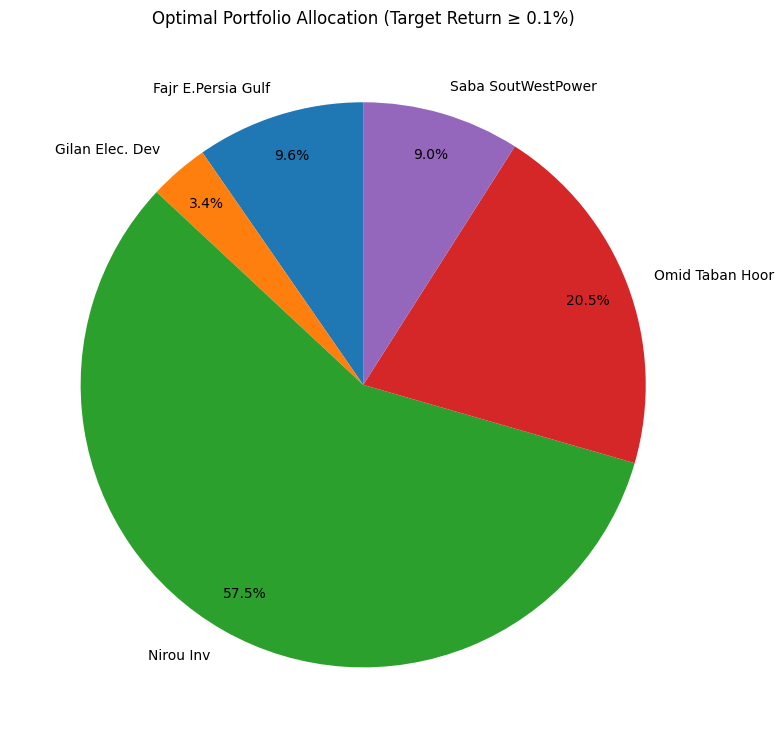

              Company  Weight
0      Bargh Mapna Co  0.0000
1         Damavand Co  0.0000
2  Fajr E.Persia Gulf  0.0964
3     Gilan Elec. Dev  0.0342
4          Mobin Petr  0.0000
5           Nirou Inv  0.5748
6     Omid Taban Hoor  0.2045
7      Peyvand Gostar  0.0000
8  Saba SoutWestPower  0.0902
9  Zagros Kosar Power  0.0000


In [18]:
import numpy as np # type: ignore

# 1: calculating the monthly return and removing NAN columns
monthly_returns = returns_df.resample('ME').mean()
monthly_returns_clean = monthly_returns.dropna(axis=1)

# 2 : calculate return annualy and covariance ,
#  becouse To avoid having very small numbers,
#  I calculated the annual covariance so that
#  the optimization algorithm wouldn’t produce unrealistic results.

mean_returns = monthly_returns_clean.mean()
cov_matrix = monthly_returns_clean.cov() * 12  # annualized
num_assets = len(monthly_returns_clean.columns)


def portfolio_variance(weights, cov_matrix):
    return weights.T @ cov_matrix @ weights

def weight_constraint(weights):
    return np.sum(weights) - 1

def return_constraint(weights):
    return weights @ mean_returns.values - 0.001  # terget = minimum monthly return = 0.1%

bounds = [(0, 1) for _ in range(num_assets)]

constraints = [
    {'type': 'eq', 'fun': weight_constraint},    # summation of weights = 1
    {'type': 'ineq', 'fun': return_constraint}   # Return ≥ 0.005
]

initial_weights = np.ones(num_assets) / num_assets

# optimizing
result = minimize(
    fun=portfolio_variance,
    x0=initial_weights,
    args=(cov_matrix,),
    method='SLSQP',
    bounds=bounds,
    constraints=constraints
)

# Results
if result.success:
    optimal_weights = result.x
    variance_val = portfolio_variance(optimal_weights, cov_matrix)
    expected_return = optimal_weights @ mean_returns.values

    optimal_df = pd.DataFrame({
        'Company': monthly_returns_clean.columns,
        'Weight': optimal_weights
    })

    print(" Optimal Weights for Min Variance Portfolio with Target Return ≥ 0.5%:")
    print(optimal_df)
    print(f"\ Expected Portfolio Return: {expected_return:.4f}")
    print(f" Portfolio Variance: {variance_val:.6f}")
    print(f" Success: {result.success}")

    # Pie chart

    # setting the minimum weight like 0.0001
    threshold = 1e-4

    # filtering weights and labels
    filtered_weights = []
    filtered_labels = []

    for w, label in zip(optimal_weights, monthly_returns_clean.columns):
        if w > threshold:
            filtered_weights.append(w)
            filtered_labels.append(label)

    plt.figure(figsize=(8, 8))

    plt.pie(
        filtered_weights,
        labels=filtered_labels,
        autopct='%1.1f%%',
        startangle=90,
        pctdistance=0.85,
        labeldistance=1.1
    )

    plt.title('Optimal Portfolio Allocation (Target Return ≥ 0.1%)')
    plt.tight_layout()
    plt.show()


else:
    print(" Optimization failed:")
    print(result.message)

optimal_df['Weight'] = optimal_df['Weight'].round(4)
print(optimal_df)


## Conclusion : 

Based on the optimization results, the core of the portfolio should be centered around **Nirou Inv**. This outcome also appears logical considering the results obtained in previous sections, as this company had the highest average positive return along with a moderate standard deviation (i.e., risk), resulting in the best return-to-risk ratio. Therefore, it should receive the highest weight in the portfolio — which is exactly what has happened, with a weight of 57.5%.

## Part 2 : 

Here the only condition is the summation of all Wi should be equal to 1. (We  still have the target return = 0.1%)

 Optimal Weights with Short-Selling Allowed:
              Company    Weight
0      Bargh Mapna Co -0.072403
1         Damavand Co -0.103914
2  Fajr E.Persia Gulf  0.168490
3     Gilan Elec. Dev  0.136148
4          Mobin Petr -0.029935
5           Nirou Inv  0.417532
6     Omid Taban Hoor  0.224843
7      Peyvand Gostar  0.072237
8  Saba SoutWestPower  0.165447
9  Zagros Kosar Power  0.021555

 Expected Portfolio Return: 0.0010
 Portfolio Variance: 0.000244
✔ Success: True


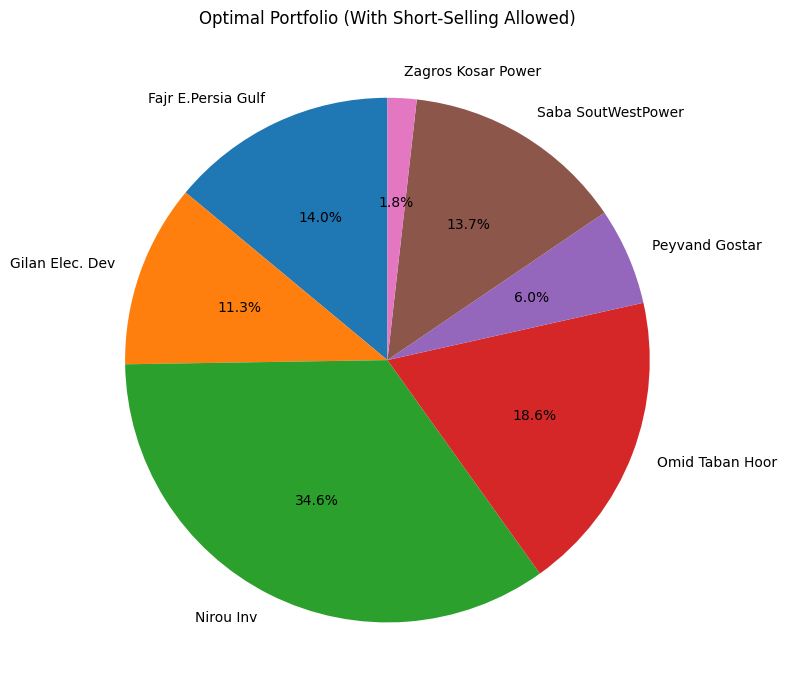

In [19]:
import numpy as np # type: ignore

mean_returns = monthly_returns_clean.mean()
cov_matrix = monthly_returns_clean.cov() * 12 

num_assets = len(mean_returns)

# Target function 
def portfolio_variance(weights, cov_matrix):
    return weights.T @ cov_matrix @ weights

# conditions
def weight_constraint(weights):
    return np.sum(weights) - 1

def return_constraint(weights):
    return weights @ mean_returns.values - 0.001  # Target return ≥ 0.1%

constraints = [
    {'type': 'eq', 'fun': weight_constraint},    #  summation of weights  = 1
    {'type': 'ineq', 'fun': return_constraint}   # return ≥ 0.1%
]

# short-selling allowed 
# initial weights
initial_weights = np.ones(num_assets) / num_assets

# Optimizing
result = minimize(
    fun=portfolio_variance,
    x0=initial_weights,
    args=(cov_matrix,),
    method='SLSQP',
    constraints=constraints  # We can have negative weights
)

# Showing Results 
if result.success:
    optimal_weights = result.x
    variance_val = portfolio_variance(optimal_weights, cov_matrix)
    expected_return = optimal_weights @ mean_returns.values

    optimal_df = pd.DataFrame({
        'Company': monthly_returns_clean.columns,
        'Weight': optimal_weights
    })

    print(" Optimal Weights with Short-Selling Allowed:")
    print(optimal_df)
    print(f"\n Expected Portfolio Return: {expected_return:.4f}")
    print(f" Portfolio Variance: {variance_val:.6f}")
    print(f"✔ Success: {result.success}")

    # Pie chart for positive weights
    filtered = optimal_df[optimal_df['Weight'] > 0.001]
    plt.figure(figsize=(8, 8))
    plt.pie(filtered['Weight'], labels=filtered['Company'], autopct='%1.1f%%', startangle=90)
    plt.title('Optimal Portfolio (With Short-Selling Allowed)')
    plt.tight_layout()
    plt.show()

else:
    print(" Optimization failed:", result.message)


## Conclusion : 

Allowing short selling enabled the model to utilize stocks with negative returns and risks or negative correlations to reduce the overall portfolio risk.

Companies like Nirou Inv and Omid Taban Hoor still played a key role, which aligns with our previous analyses.

This model produced lower risk while achieving the same or better target return → indicating improved efficiency.

## **Question 3 :**

Plotting Efficient Frontier when No Short Selling is allowed.

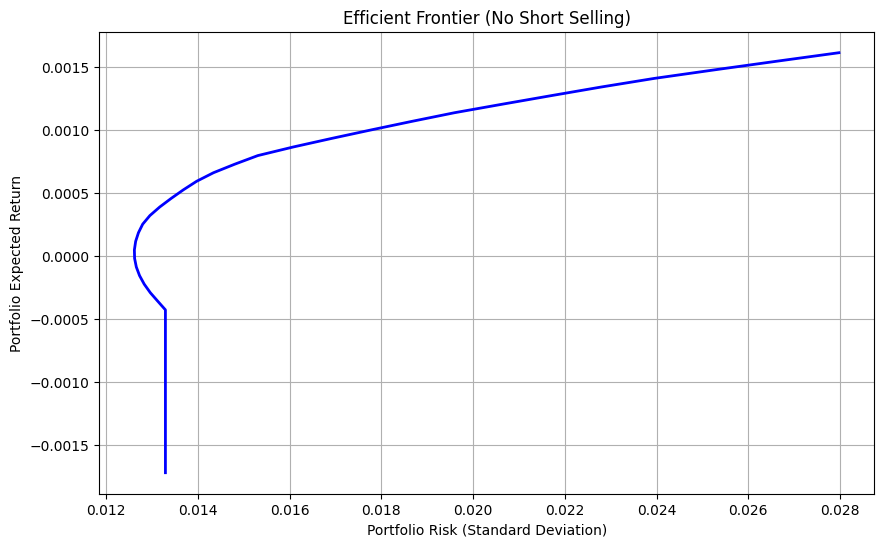

In [20]:

# A range of target returns, from the lowest average monthly return to the highest average monthly return.
target_returns = np.linspace(mean_returns.min(), mean_returns.max(), 50)

portfolio_variances = []
portfolio_returns = []
weights_list = []

def weight_sum_constraint(weights):
    return np.sum(weights) - 1

for target in target_returns:
    constraints = [
        {'type': 'eq', 'fun': weight_sum_constraint},
        {'type': 'ineq', 'fun': lambda w: w @ mean_returns.values - target}
    ]
    initial_weights = np.ones(num_assets) / num_assets

    result = minimize(
        portfolio_variance,
        initial_weights,
        args=(cov_matrix,),
        method='SLSQP',
        bounds=bounds,
        constraints=constraints
    )
    
    if result.success:
        portfolio_variances.append(result.fun)
        portfolio_returns.append(target)
        weights_list.append(result.x)
    else:
        
        continue

# Plotting Efficient Frontier when no short selling is allowed
plt.figure(figsize=(10,6))
plt.plot(np.sqrt(portfolio_variances), portfolio_returns, 'b-', linewidth=2)
plt.xlabel('Portfolio Risk (Standard Deviation)')
plt.ylabel('Portfolio Expected Return')
plt.title('Efficient Frontier (No Short Selling)')
plt.grid(True)
plt.show()


## Plot interpretation

This efficient frontier is plotted under the condition that short selling is not allowed. The portfolios along this curve provide the best possible combination of assets based on the expected return and risk.

## **Question 4 part 1 :**

Portfolio Return (Risky): 0.0010
Portfolio Std Dev (Risky): 0.0178


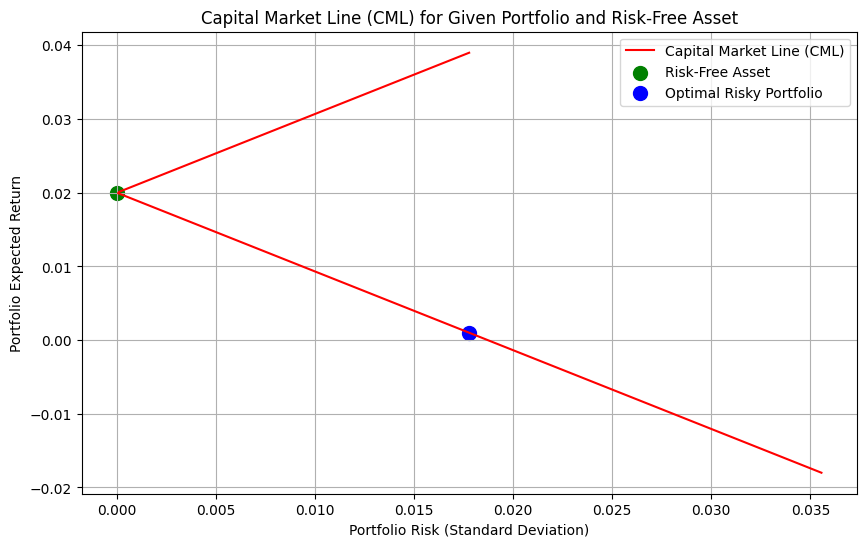

In [21]:

# The weights of optimal portfolio in question 2 part 1
optimal_weights = np.array([
    6.938894e-17,
    2.775558e-17,
    9.636357e-02,
    3.417373e-02,
    0.000000e+00,
    5.747547e-01,
    2.045472e-01,
    2.775558e-17,
    9.016078e-02,
    1.387779e-17
])


portfolio_return = optimal_weights @ mean_returns.values  # Return of Risky portfolio
# Variance of Risky portfolio :
portfolio_variance = optimal_weights.T @ cov_matrix @ optimal_weights
portfolio_std = np.sqrt(portfolio_variance)

print(f"Portfolio Return (Risky): {portfolio_return:.4f}")
print(f"Portfolio Std Dev (Risky): {portfolio_std:.4f}")

# Return of Risk free asset
R_rf = 0.02  # 2% monthly

# Function for calculating combined return of the risk free asset weight
def combined_return(w_rf):
    w_p = 1 - w_rf
    return w_p * portfolio_return + w_rf * R_rf

# Function for calculating combined Varance
def combined_variance(w_rf):
    w_p = 1 - w_rf
    return (w_p ** 2) * portfolio_variance  # Which the variance of risk free asset is 0

# the range of weights is (-1 , 2) because: 
#This range was selected because it allows us to see the entire Capital Market Line
#from the conservative case, where only the risk-free asset is held, 
#to the aggressive case, where borrowing is used to invest more in the 
#risky portfolio.

w_rf_range = np.linspace(-1, 2, 300)

combined_returns = [combined_return(w) for w in w_rf_range]
combined_stds = np.sqrt([combined_variance(w) for w in w_rf_range])

# plotting CML
plt.figure(figsize=(10,6))
plt.plot(combined_stds, combined_returns, color='red', label='Capital Market Line (CML)')


# plotting the scatters of risky portfolio and risk free asset
plt.scatter(0, R_rf, color='green', s=100, label='Risk-Free Asset')
plt.scatter(portfolio_std, portfolio_return, color='blue', s=100, label='Optimal Risky Portfolio')

plt.xlabel('Portfolio Risk (Standard Deviation)')
plt.ylabel('Portfolio Expected Return')
plt.title('Capital Market Line (CML) for Given Portfolio and Risk-Free Asset')
plt.legend()
plt.grid(True)
plt.show()


## **Plot interpretation :**

The optimal risky portfolio at is the tangency point where the CML touches the efficient frontier, indicating the best risky portfolio to combine with the risk-free asset.

## Part 2: 

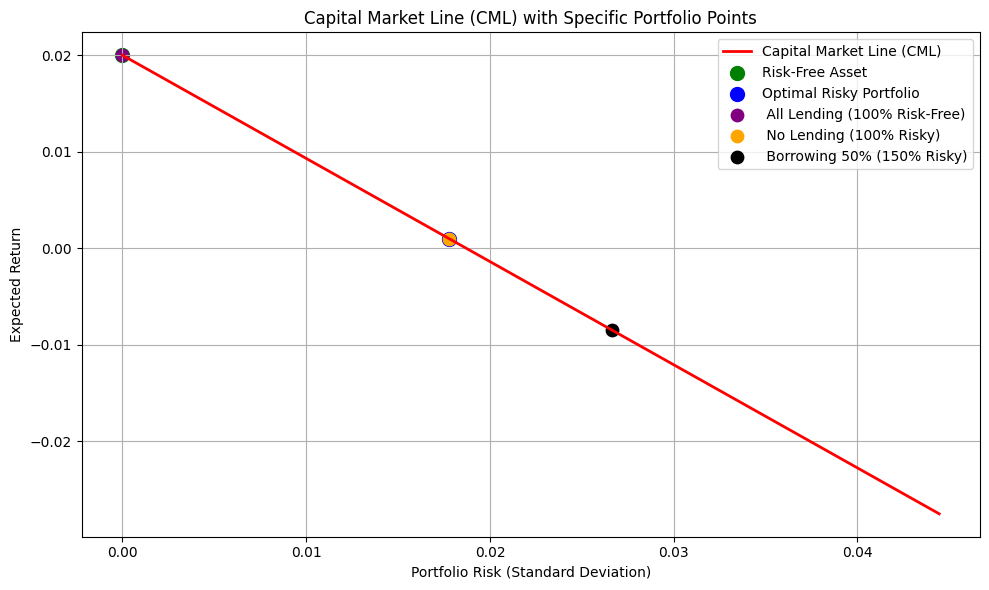

In [22]:


R_rf = 0.02  # the return of risk free asset
R_p = portfolio_return  # The return of Risky portfolio
sigma_p = portfolio_std  # The variance of Risky portfolio


# The range of CML
sigma_range = np.linspace(0, sigma_p * 2.5, 300)
CML = R_rf + ((R_p - R_rf) / sigma_p) * sigma_range


# calculating the wanted points
points = {
    " All Lending (100% Risk-Free)": {
        "w_rf": 1.0,
        "w_risky": 0.0
    },
    " No Lending (100% Risky)": {
        "w_rf": 0.0,
        "w_risky": 1.0
    },
    " Borrowing 50% (150% Risky)": {
        "w_rf": -0.5,
        "w_risky": 1.5
    }
}

# Calculating Risk and Return of each point
for label, vals in points.items():
    w_rf = vals["w_rf"]
    w_risky = vals["w_risky"]
    R_comb = w_rf * R_rf + w_risky * R_p
    sigma_comb = abs(w_risky) * sigma_p 
    vals["return"] = R_comb
    vals["std"] = sigma_comb

# PLOT
plt.figure(figsize=(10,6))
plt.plot(sigma_range, CML, 'r-', linewidth=2, label='Capital Market Line (CML)')

# POINT of risk free asset
plt.scatter(0, R_rf, color='green', s=100, label='Risk-Free Asset')

# POINT of optimal portfolio
plt.scatter(sigma_p, R_p, color='blue', s=100, label='Optimal Risky Portfolio')

colors = ['purple', 'orange', 'black']
for (label, vals), color in zip(points.items(), colors):
    plt.scatter(vals["std"], vals["return"], color=color, s=80, label=label)

plt.xlabel('Portfolio Risk (Standard Deviation)')
plt.ylabel('Expected Return')
plt.title('Capital Market Line (CML) with Specific Portfolio Points')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


1) Capital Market Line (Red Line):

It shows a downward slope from a high expected return to a negative return as risk increases beyond the optimal point.

2) Risk-Free Asset (Green Dot):

implied as the starting point of the CML, typically at (0, 0.02) based on context from similar charts, representing zero risk and a 2% expected return.

3) All Lending (100% Risk-Free) (Purple Dot):

Located at (0, 0.02), indicating zero risk with a 2% expected return, representing a portfolio fully invested in the risk-free asset.

4) No Lending (100% Risky) (Orange Dot):

Positioned at approximately (0.018, 0.001), showing a standard deviation of 0.018 and an expected return of 0.001, representing almost full investment in the optimal risky portfolio without leveraging.


5) Borrowing 50% (150% Risky) (Black Dot):

Located at (0.027, -0.009), with a standard deviation of 0.027 and an expected return of -0.9%, indicating a leveraged portfolio where 50% borrowing increases risk and reduces return due to borrowing costs.

## **Question 5 :**

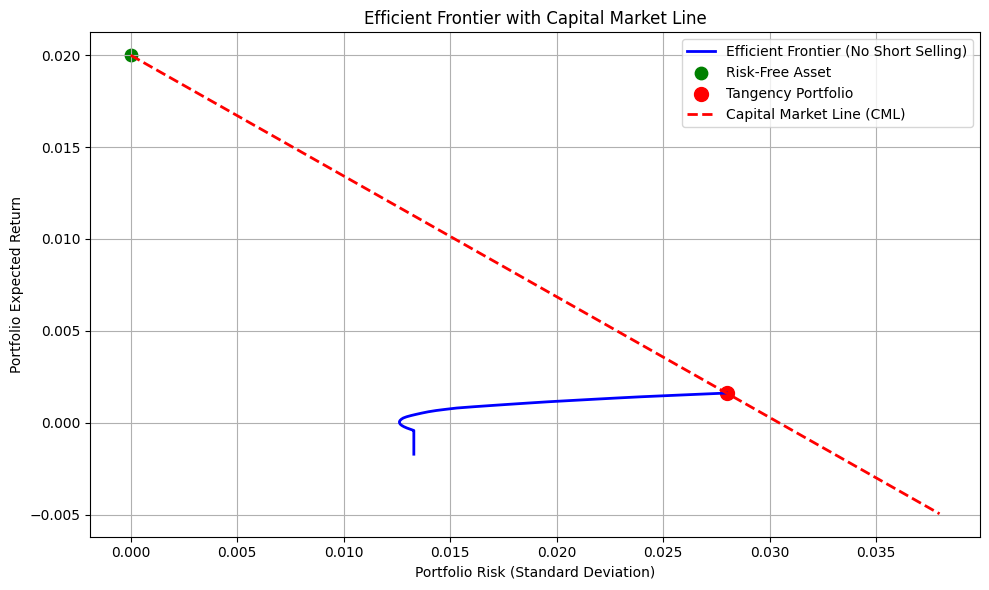

In [15]:
# Return of risk free asset
R_f = 0.02  

# calculating SD from variances
portfolio_std = np.sqrt(portfolio_variances)

# Calculating Sharp ratio for all the portfolios on efficient frontier
sharpe_ratios = [(r - R_f) / s if s > 0 else -np.inf for r, s in zip(portfolio_returns, portfolio_std)]

# Finding  the portfolio index with the highest Sharpe ratio
max_sharpe_idx = np.argmax(sharpe_ratios)

# Coordinates of the portfolio tangent to the Capital Market Line (CML)
tangent_return = portfolio_returns[max_sharpe_idx]
tangent_std = portfolio_std[max_sharpe_idx]

# Plotting the Efficient Frontier

plt.figure(figsize=(10, 6))
plt.plot(portfolio_std, portfolio_returns, 'b-', linewidth=2, label='Efficient Frontier (No Short Selling)')

# plotting the point off risk free asset
plt.scatter(0, R_f, color='green', s=80, label='Risk-Free Asset')

# Plotting the Tangency Portfolio Point
plt.scatter(tangent_std, tangent_return, color='red', s=100, label='Tangency Portfolio')

# Plotting CML
cml_x = np.linspace(0, max(portfolio_std) + 0.01, 100)
cml_y = R_f + ((tangent_return - R_f) / tangent_std) * cml_x
plt.plot(cml_x, cml_y, 'r--', linewidth=2, label='Capital Market Line (CML)')

plt.xlabel('Portfolio Risk (Standard Deviation)')
plt.ylabel('Portfolio Expected Return')
plt.title('Efficient Frontier with Capital Market Line')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


The optimal Capital Market Line is the one that is tangent to the efficient frontier with the steepest slope — that is, the highest return-to-risk ratio. It starts from the risk-free asset and passes through the tangency portfolio.

## Interpretation:
The efficient frontier (blue curve) guides the selection of the best risky portfolios, while the CML (red line) extends this to include risk-free asset combinations, offering a broader range of efficient portfolios.

The tangency portfolio is the cornerstone for CML-based investing, where investors can achieve any point along the CML by adjusting the proportion of risk-free asset and tangency portfolio.

Portfolios below the CML or outside the efficient frontier are suboptimal, as they offer lower returns for the same risk level.

## **Question 6 :**

In [24]:

import statsmodels.api as sm # type: ignore

R_f = 0.02  # Monthly risk-free rate

monthly_returns = monthly_returns_clean.copy()

market_return_series = monthly_returns.mean(axis=1)

# excess returns
excess_returns = monthly_returns.subtract(R_f)
market_excess_return = market_return_series - R_f

# DataFrame 
X = pd.DataFrame({'market_excess': market_excess_return})

# classify based on beta
def classify_stock(beta):
    if beta < 0.8:
        return 'Defensive'
    elif beta > 1.2:
        return 'Aggressive'
    else:
        return 'Neutral'


result_data = []

# CAPM for each company
for company in monthly_returns.columns:
    y = excess_returns[company]
    X_with_const = sm.add_constant(X)  # Adding alpha

    model = sm.OLS(y, X_with_const).fit()

    beta = model.params['market_excess']
    std_dev = monthly_returns[company].std()
    stock_type = classify_stock(beta)

    result_data.append({
        'Company': company,
        'Beta (CAPM)': beta,
        'Monthly Std Dev': std_dev,
        'Type': stock_type
    })

# Dataframe
capm_df = pd.DataFrame(result_data).set_index('Company')
capm_df = capm_df.round(4)

print("📊 CAPM Results with Classification (Using Simple Market Average):")
print(capm_df)


📊 CAPM Results with Classification (Using Simple Market Average):
                    Beta (CAPM)  Monthly Std Dev        Type
Company                                                     
Bargh Mapna Co           1.3828           0.0094  Aggressive
Damavand Co              1.3670           0.0087  Aggressive
Fajr E.Persia Gulf       1.0956           0.0069     Neutral
Gilan Elec. Dev          0.9396           0.0044     Neutral
Mobin Petr               0.9975           0.0081     Neutral
Nirou Inv                0.7971           0.0081   Defensive
Omid Taban Hoor          0.8274           0.0042     Neutral
Peyvand Gostar           1.3268           0.0060  Aggressive
Saba SoutWestPower      -0.0000           0.0000   Defensive
Zagros Kosar Power       1.2661           0.0063  Aggressive


## Conclusion : 

These results indicate that if you are risk-tolerant, aggressive stocks like Bargh Mapna Co, Damavand Co, Peyvand Gostar, and Zagros Kosar Power are more suitable for you. If you are risk-averse, defensive stocks such as Nirou Inv and Saba SouthWestPower are better options. For those with moderate risk tolerance, neutral stocks like Fajr E. Persia Gulf or Mobin Petr are appropriate.

## **Question 7 :**

In [17]:

# market mean return 
market_mean_return = market_return_series.mean()

# Final list
ratios_data = []

for company in monthly_returns.columns:
    R_i = monthly_returns[company].mean()
    beta_i = capm_df.loc[company, 'Beta (CAPM)']
    std_i = capm_df.loc[company, 'Monthly Std Dev']

    # Sharpe Ratio
    sharpe = (R_i - R_f) / std_i if std_i > 0 else np.nan

    # Treynor Ratio
    treynor = (R_i - R_f) / beta_i if beta_i != 0 else np.nan

    # Jensen's Alpha
    expected_return_capm = R_f + beta_i * (market_mean_return - R_f)
    jensen_alpha = R_i - expected_return_capm

    ratios_data.append({
        'Company': company,
        'Sharpe Ratio': sharpe,
        'Treynor Ratio': treynor,
        'Jensen Alpha': jensen_alpha
    })

# Final dataframe
ratios_df = pd.DataFrame(ratios_data).set_index('Company')
ratios_df = ratios_df.round(4)

print("Performance Ratios for All Companies:")
print(ratios_df)


Performance Ratios for All Companies:
                    Sharpe Ratio  Treynor Ratio  Jensen Alpha
Company                                                      
Bargh Mapna Co           -2.2889        -0.0156        0.0067
Damavand Co              -2.4962        -0.0159        0.0062
Fajr E.Persia Gulf       -2.8954        -0.0182        0.0024
Gilan Elec. Dev          -4.5875        -0.0215       -0.0010
Mobin Petr               -2.6229        -0.0213       -0.0009
Nirou Inv                -2.2702        -0.0231       -0.0021
Omid Taban Hoor          -4.6712        -0.0237       -0.0027
Peyvand Gostar           -3.4320        -0.0155        0.0065
Saba SoutWestPower           NaN            NaN       -0.0200
Zagros Kosar Power       -3.3200        -0.0165        0.0049


## Interpretation of the dataframe: 

We know that our evaluation is based on the following three criteria:

Sharpe Ratio – the higher, the better and Treynor Ratio – the higher, the better and Jensen’s Alpha – a positive value indicates performance better than expected by the CAPM

Now, based on these criteria, we can say that : 

1   Bargh Mapna Co	    ->  Highest Jensen Alpha and best Treynor

2	Peyvand Gostar      ->	Strong performance beyond CAPM

3	Zagros Kosar Power  ->	Balanced risk-return metrice

Risk-Seeking  ->  Bargh Mapna Co, Peyvand Gostar

Moderate Risk ->  Zagros Kosar Power, Damavand Co

Risk-Averse	  ->  Nirou Inv , Saba 



## **Question 8 : Part 1**

Aligned data length: 25


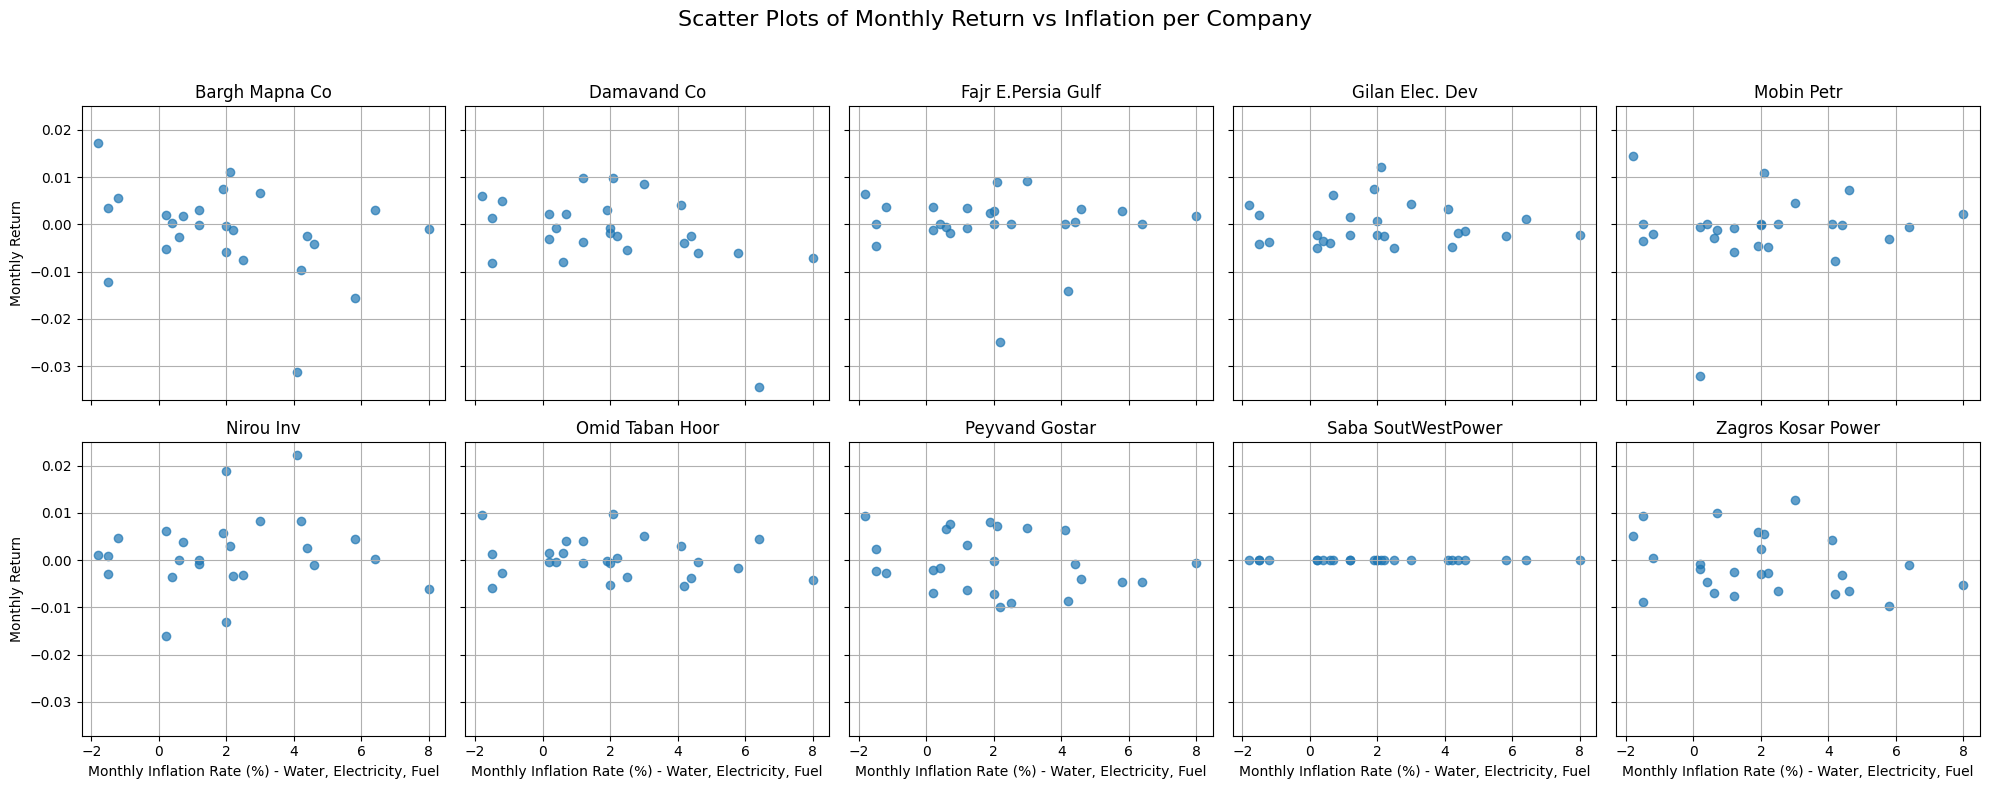

In [26]:


# These inflation data relate to water, electricity, and fuel supply and
# were obtained from the Statistics Center website.
# The figures were copied from the Excel file covering the 
# period from Farvardin 1402 to Ordibehesht 1404.

inflation_values = [
    2.6, 0.3, 5.8, 4.2, 1.2, 2.0, 0.6, 0.7, 0.2, 0.2, 6.4, 3.0, 8.0, -1.5, 2.2, -1.2,
    4.4, 1.9, 4.6, 2.1, -1.5, 0.4, 2.5, 2.0, 4.1, -1.8, 1.2, 2.0, 7.3, 2.4, 5.3, 1.6,
    3.6, 2.9, 2.7, 0.7, 6.5, 2.1
]

# Creating a time index from Farvardin 1402 onward on a monthly basis.
# Here, I started with the Gregorian date, for example, 21/3/2023, which corresponds to Farvardin 1402.

dates = pd.date_range(start='2023-03-21', periods=len(inflation_values), freq='MS')

# creating the time series of inflation
monthly_inflation = pd.Series(inflation_values, index=dates)

#print("monthly_inflation")
#print(monthly_inflation)

monthly_returns.index = monthly_returns.index.to_period('M').to_timestamp('M')
monthly_inflation.index = monthly_inflation.index.to_period('M').to_timestamp('M')

# Index alignment

aligned_returns, aligned_inflation = monthly_returns.align(monthly_inflation, join='inner', axis=0)

print(f"Aligned data length: {len(aligned_returns)}")  

# scatter plot for each company

n_companies = len(aligned_returns.columns)
cols = 5  
rows = int(np.ceil(n_companies / cols)) 

fig, axes = plt.subplots(rows, cols, figsize=(20, 4*rows), sharex=True, sharey=True)
axes = axes.flatten()

for i, company in enumerate(aligned_returns.columns):
    ax = axes[i]
    ax.scatter(aligned_inflation, aligned_returns[company], alpha=0.7)
    ax.set_title(company)
    ax.grid(True)
    if i // cols == rows - 1: 
        ax.set_xlabel('Monthly Inflation Rate (%) - Water, Electricity, Fuel')
    if i % cols == 0:  
        ax.set_ylabel('Monthly Return')


for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle('Scatter Plots of Monthly Return vs Inflation per Company', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()



## **Part 2:**

In [27]:

results = {}

for company in aligned_returns.columns:
    y = aligned_returns[company]
    X = aligned_inflation
    X = sm.add_constant(X)  # adding Intercept
    
    model = sm.OLS(y, X).fit()
    results[company] = model
    
    print(f"Regression Results for {company}:")
    print(model.summary())
    print("\n" + "="*80 + "\n")


Regression Results for Bargh Mapna Co:
                            OLS Regression Results                            
Dep. Variable:         Bargh Mapna Co   R-squared:                       0.118
Model:                            OLS   Adj. R-squared:                  0.080
Method:                 Least Squares   F-statistic:                     3.075
Date:                Sat, 12 Jul 2025   Prob (F-statistic):             0.0928
Time:                        22:04:22   Log-Likelihood:                 83.150
No. Observations:                  25   AIC:                            -162.3
Df Residuals:                      23   BIC:                            -159.9
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        

c:\Users\az\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\regression\linear_model.py:1782: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
c:\Users\az\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\regression\linear_model.py:1871: RuntimeWarning: invalid value encountered in scalar divide
  return self.mse_model/self.mse_resid
c:\Users\az\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\regression\linear_model.py:955: RuntimeWarning: divide by zero encountered in log
  llf = -nobs2*np.log(2*np.pi) - nobs2*np.log(ssr / nobs) - nobs2
c:\Users\az\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\stats\stattools.py:50: RuntimeWarning: invalid value encountered in scalar divide
  dw = np.sum(diff_resids**2, axis=axis) / np.sum(resids**2, axis=axis)


Based on the output of this regression, it can be said that:

1. For almost all companies, the coefficient of the inflation variable is small and negative, except for Nirou Inv, where it is positive but very small. This means there is no strong or positive relationship observed between inflation and the companies' returns.

2. The R-squared values for all models are very low, indicating that inflation alone cannot adequately explain the companies' returns.

3. Most p-values for the inflation coefficient are above 0.05, meaning the relationship is not statistically significant. The only exception is Omid Taban Hoor, where the p-value is approximately 0.019, indicating significance.

## **Part 3 :**


In [28]:

results = []

for company in monthly_returns.columns:

    df = pd.concat([monthly_returns[company], monthly_inflation], axis=1, join='inner')
    df.columns = ['company_return', 'inflation']
    df.dropna(inplace=True)


    y = df['company_return']
    X = sm.add_constant(df['inflation'])

    # fitting regression model
    model = sm.OLS(y, X).fit()

    beta = model.params['inflation']
    var_market = df['inflation'].var()
    var_company = df['company_return'].var()
    systematic_risk = beta**2 * var_market
    unsystematic_risk = var_company - systematic_risk

    results.append({
        'Company': company,
        'Beta': beta,
        'Total Variance': var_company,
        'Systematic Variance': systematic_risk,
        'Unsystematic Variance': unsystematic_risk
    })


results_df = pd.DataFrame(results)
print(results_df)


              Company      Beta  Total Variance  Systematic Variance  \
0      Bargh Mapna Co -0.001273        0.000089         1.053036e-05   
1         Damavand Co -0.001519        0.000075         1.498830e-05   
2  Fajr E.Persia Gulf -0.000121        0.000047         9.530031e-08   
3     Gilan Elec. Dev -0.000051        0.000019         1.677010e-08   
4          Mobin Petr  0.000265        0.000065         4.554644e-07   
5           Nirou Inv  0.000385        0.000065         9.609693e-07   
6     Omid Taban Hoor -0.000309        0.000018         6.186993e-07   
7      Peyvand Gostar -0.000532        0.000037         1.835960e-06   
8  Saba SoutWestPower  0.000000        0.000000         0.000000e+00   
9  Zagros Kosar Power -0.000637        0.000040         2.637615e-06   

   Unsystematic Variance  
0               0.000079  
1               0.000060  
2               0.000047  
3               0.000019  
4               0.000065  
5               0.000064  
6               0.

## Conclusion for this part: 

1) The betas are very small and close to zero, indicating that the companies’ returns are weakly or practically not affected by changes in the inflation rate.

2) The amount of systematic risk for all companies is very low; in other words, a negligible portion of the total risk of the companies is caused by inflation.

3. The dominant risk is unsystematic; more than 90% of the total risk of the companies stems from unsystematic risk (internal company factors), meaning the return fluctuations of these companies are mostly related to their own specific factors rather than the inflation rate.

4. Overall, if an investor wants to reduce investment risk through diversification, the unsystematic risk of these companies should be prioritized in the analysis.

## **Part 4 :**

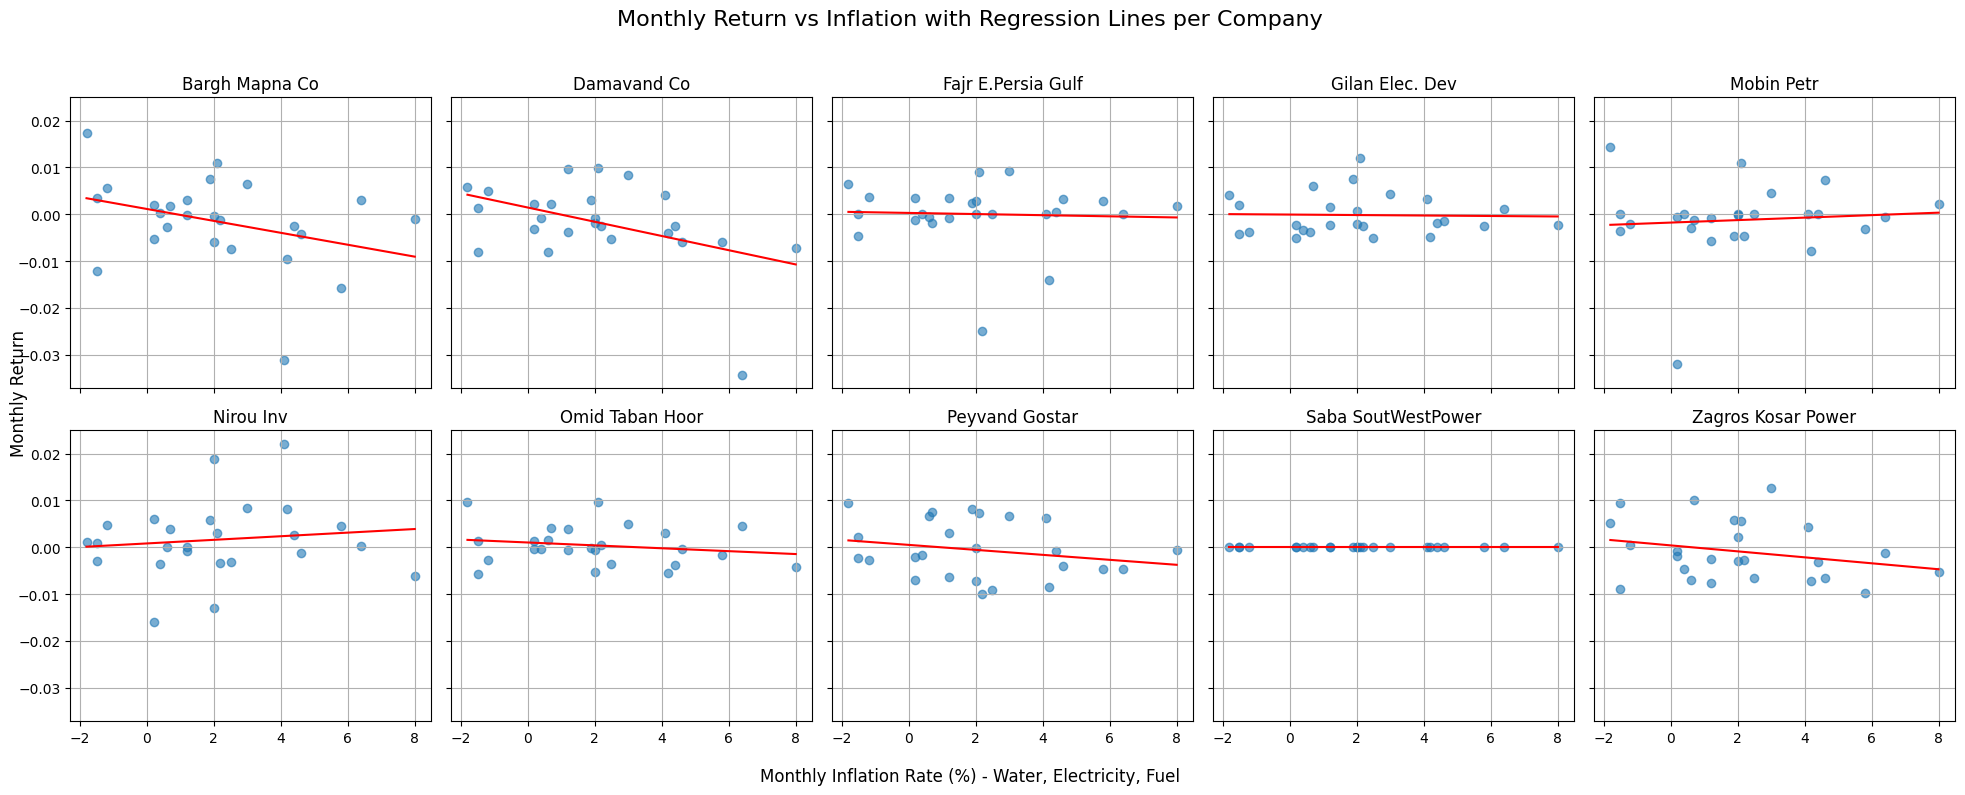

In [29]:

n_companies = len(aligned_returns.columns)
cols = 5  
rows = int(np.ceil(n_companies / cols))  

fig, axes = plt.subplots(rows, cols, figsize=(20, 4*rows), sharex=True, sharey=True)
axes = axes.flatten()  

for i, company in enumerate(aligned_returns.columns):
    ax = axes[i]
    
    y = aligned_returns[company]
    X = aligned_inflation
    X_const = sm.add_constant(X)
    
    # Regression model
    model = sm.OLS(y, X_const).fit()
    
    
    ax.scatter(X, y, alpha=0.6)
    
    # regression line
    x_vals = np.linspace(X.min(), X.max(), 100)
    x_vals_const = sm.add_constant(x_vals)
    y_vals = model.predict(x_vals_const)
    ax.plot(x_vals, y_vals, color='red')
    
    ax.set_title(company)
    ax.grid(True)


for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle('Monthly Return vs Inflation with Regression Lines per Company', fontsize=16)
fig.supxlabel('Monthly Inflation Rate (%) - Water, Electricity, Fuel')
fig.supylabel('Monthly Return')
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


## **Question 9 :**

In [30]:

results_apt = []

aligned_returns, aligned_inflation = monthly_returns_clean.align(monthly_inflation, join='inner', axis=0)

aligned_inflation.name = 'inflation'

for company in aligned_returns.columns:
    y = aligned_returns[company].dropna()
    X = aligned_inflation.loc[y.index].copy() 
    X = sm.add_constant(X)  # adding alpha
    
    model = sm.OLS(y, X).fit()
    
    alpha = model.params['const']
    beta = model.params['inflation']  
    r_squared = model.rsquared
    
    results_apt.append({
        'Company': company,
        'Alpha': alpha,
        'Beta': beta,
        'R-squared': r_squared
    })

results_apt_df = pd.DataFrame(results_apt)
print(results_apt_df)


              Company     Alpha      Beta  R-squared
0      Bargh Mapna Co  0.001117 -0.001273   0.117930
1         Damavand Co  0.001424 -0.001519   0.199753
2  Fajr E.Persia Gulf  0.000272 -0.000121   0.002030
3     Gilan Elec. Dev -0.000080 -0.000051   0.000876
4          Mobin Petr -0.001793  0.000265   0.006960
5           Nirou Inv  0.000816  0.000385   0.014727
6     Omid Taban Hoor  0.001019 -0.000309   0.034796
7      Peyvand Gostar  0.000507 -0.000532   0.050197
8  Saba SoutWestPower  0.000000  0.000000        NaN
9  Zagros Kosar Power  0.000402 -0.000637   0.066601


c:\Users\az\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\regression\linear_model.py:1782: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.centered_tss


As mentioned in part three of question 8, this APT model with inflation as the only factor cannot adequately explain the companies’ returns because the results show that : 

1. inflation does not have a strong and direct impact on the companies’ monthly returns. 

2. The low or near-zero R-squared values indicate that the inflation-only model fails to explain a large portion of the variations in stock returns. 

3. Additionally, the alpha values are generally close to zero, which suggests that factors other than inflation predominantly affect the stock returns.

## **Question 10 : Part 1**

In [31]:

# confidence level
confidence_level = 0.95
alpha = 1 - confidence_level  # 0.05

# Historical VaR 
def historical_var(returns, alpha=0.05):
    return -np.percentile(returns, 100 * alpha)

# Parametric VaR
def parametric_var(returns, alpha=0.05):
    mu = returns.mean()
    sigma = returns.std()
    from scipy.stats import norm # type: ignore
    z = norm.ppf(alpha)  
    var = -(mu + z * sigma)
    return var

# Montcarlo 
def monte_carlo_var(returns, alpha=0.05, num_simulations=10000):
    mu = returns.mean()
    sigma = returns.std()
    simulated_returns = np.random.normal(mu, sigma, num_simulations)
    var = -np.percentile(simulated_returns, 100 * alpha)
    return var


var_results = []

for company in returns_df.columns:
    daily_returns = returns_df[company].dropna()
    
    hist = historical_var(daily_returns, alpha)
    param = parametric_var(daily_returns, alpha)
    mc = monte_carlo_var(daily_returns, alpha)
    
    var_results.append({
        'Company': company,
        'Historical VaR (95%)': hist,
        'Parametric VaR (95%)': param,
        'Monte Carlo VaR (95%)': mc
    })

var_df = pd.DataFrame(var_results).set_index('Company')

print(var_df)


                    Historical VaR (95%)  Parametric VaR (95%)  \
Company                                                          
Bargh Mapna Co                  0.040609              0.053733   
Damavand Co                     0.029013              0.052851   
Fajr E.Persia Gulf              0.008719              0.070056   
Gilan Elec. Dev                 0.026878              0.026588   
Mobin Petr                      0.015273              0.055579   
Nirou Inv                       0.047375              0.050294   
Omid Taban Hoor                 0.027394              0.025990   
Peyvand Gostar                  0.034063              0.037062   
Saba SoutWestPower             -0.000000             -0.000000   
Zagros Kosar Power              0.039812              0.036958   

                    Monte Carlo VaR (95%)  
Company                                    
Bargh Mapna Co                   0.053044  
Damavand Co                      0.053570  
Fajr E.Persia Gulf             

1. In this output, we can see that the parametric VaR and Monte Carlo VaR values are usually very close to each other.

2. The historical VaR is generally lower, which means that large losses have occurred less frequently in the past.

3. For example, for the company Fajr E. Persia Gulf, the parametric VaR is much higher than the historical VaR, indicating that the risk of this company during extreme market downturns is likely greater than what past data suggests.

## Important point

However, these results show that the company Nirou Inv has a high VaR, even though from previous sections we had concluded that based on its beta and standard deviation—it is suitable for risk-averse investors. This means that the company generally carries low risk under normal conditions, but during market stress or crisis situations, there is a higher likelihood of large losses. And that is exactly what VaR is meant to reveal.

## Part 2

In [32]:

# converting daiy VaR to monthly VaR
monthly_var_df = var_df * np.sqrt(22)

# in Rial terms (1 million)
investment = 1_000_000
monthly_var_rial = (monthly_var_df * investment).round(0).astype(int)


print("Monthly VaR for 1,000,000 Toman Investment (95% Confidence):\n")
print(monthly_var_rial)


Monthly VaR for 1,000,000 Toman Investment (95% Confidence):

                    Historical VaR (95%)  Parametric VaR (95%)  \
Company                                                          
Bargh Mapna Co                    190475                252030   
Damavand Co                       136082                247893   
Fajr E.Persia Gulf                 40895                328590   
Gilan Elec. Dev                   126069                124707   
Mobin Petr                         71635                260687   
Nirou Inv                         222207                235902   
Omid Taban Hoor                   128488                121906   
Peyvand Gostar                    159767                173838   
Saba SoutWestPower                     0                     0   
Zagros Kosar Power                186734                173350   

                    Monte Carlo VaR (95%)  
Company                                    
Bargh Mapna Co                     248798  
Damavand Co  

## In this section, we will interpret the results of two companies.

## Nirou Inv Co : 

Historical VaR = Based on actual past data, in 95% of the cases, the monthly loss on a one million toman investment in this company will not exceed 222,207 tomans.

Parametric VaR = Assuming a normal distribution of returns, in 95% of the cases, the monthly loss will not exceed 235,902 tomans. This value is slightly higher than the Historical VaR, which may indicate that the normality assumption predicts a slightly higher risk.

Monte Carlo VaR = Using Monte Carlo simulation, in the worst 5% of scenarios, losses are not expected to exceed 234,403 tomans. This number is very close to the parametric VaR, suggesting that the random simulation also predicts a similar level of risk.

Overall, the risk for Nirou Inv is relatively moderate and balanced, and the differences between the models are not significant; this is why in previous sections it was also deemed suitable for risk-averse investors.


## Bargh Mapna Co : 

Historical VaR = the value is 190,475. This means that if you had invested one million tomans in this company, in the worst 5% of months (i.e., during very poor market conditions), you could lose this amount or more. In other words, in 95% of the time, your loss would be less than this amount.

Parametric VaR = In 95% of the time, your monthly loss would not exceed 252,030 tomans. Since this number is higher than the Historical VaR, it suggests that under the assumption of a normal distribution, the company appears to carry greater risk.

Monte Carlo = Assuming that the future behavior of the market is similar to the simulated scenarios, in the worst 5% of simulated cases, the maximum expected loss over the next month is about 251,806 tomans.

## Part 3 : 

In [34]:
from scipy import stats # type: ignore

# 1. annually SD of portfolio
portfolio_variance_annual = optimal_weights.T @ cov_matrix @ optimal_weights
portfolio_std_annual = np.sqrt(portfolio_variance_annual)

# 2. Converting to monthly SD
portfolio_std_monthly = portfolio_std_annual / np.sqrt(12)

# 3. Z amount for 95% 
Z_95 = stats.norm.ppf(0.05)  

# 4. Parametric VaR
parametric_VaR_monthly = - Z_95 * portfolio_std_monthly

print(f"Parametric Monthly VaR (95%) for the portfolio: {parametric_VaR_monthly:.6f}")


Parametric Monthly VaR (95%) for the portfolio: 0.008443


This means that in normal months, with 95% confidence, the maximum potential loss of the portfolio is about 0.8443% of its total value. If the investment is one million tomans, the potential monthly loss in the worst 5% of months will not exceed 8,443 tomans, which is a very favorable result.

## Part 4 : 

In this section, I used the Proportion of Failures (PoF) test as a backtest method, which is one of the standard tests for VaR. This method counts the number of times the actual loss exceeds the VaR and compares it with the expected failure rate. Then, using a statistical test, we determine whether the model performs well or not.

In [35]:

from scipy.stats import binomtest # type: ignore


# calculating monthly return of portfolio
portfolio_returns = monthly_returns_clean @ optimal_weights

# mean and variance of portfolio
mean_returns = monthly_returns_clean.mean()
cov_matrix = monthly_returns_clean.cov()

# monthly variance
portfolio_var_monthly = optimal_weights.T @ cov_matrix.values @ optimal_weights
portfolio_std_monthly = np.sqrt(portfolio_var_monthly)
portfolio_mean_monthly = portfolio_returns.mean()

# Parametric VaR for 95% confidence
# We have it from previous section 
# parametric_VaR_monthly

print(f"Parametric Monthly VaR (95% confidence): {parametric_VaR_monthly:.6f}")

# Backtesting the VaR Model Using the Binomial Test

# Number of months
N = len(portfolio_returns)

# Number of periods where the actual loss exceeded the predicted VaR
violations = np.sum(portfolio_returns < -parametric_VaR_monthly)

p = 0.05

# test
test_result = binomtest(violations, N, p, alternative='greater')

print(f"\nBacktesting Results:")
print(f"Total periods (N): {N}")
print(f"Number of VaR violations: {violations}")
print(f"Expected violations (5% of N): {N * p:.2f}")
print(f"Binomial test p-value: {test_result.pvalue:.4f}")

if test_result.pvalue < 0.05:
    print("Result: Reject null hypothesis — VaR model may be inaccurate.")
else:
    print("Result: Fail to reject null hypothesis — VaR model is adequate.")


Parametric Monthly VaR (95% confidence): 0.008443

Backtesting Results:
Total periods (N): 25
Number of VaR violations: 2
Expected violations (5% of N): 1.25
Binomial test p-value: 0.3576
Result: Fail to reject null hypothesis — VaR model is adequate.


The monthly parametric VaR is 0.007443, which means that with 95% confidence, we expect the maximum monthly loss not to exceed approximately 0.74% of the investment.

The number of periods (N) is 25 months, covering the portfolio’s return data.

The number of times the return fell below -VaR (violations) was 2. In other words, in two months the loss was worse than the predicted VaR.

We expected about 5% of 25 months, i.e., 1.25 months, to have returns worse than the VaR.

The p-value of the binomial test is 0.3576, which is greater than 0.05; this means the test statistic indicates that the number of VaR violations, given the 95% confidence level, is perfectly reasonable and normal.

Therefore, we conclude that our VaR model is sufficiently accurate and valid, and we cannot say that the model is incorrect.